# Wine Quality Prediction using Machine Learning

This project implements an end-to-end machine learning pipeline to classify wine quality based on chemical properties.

## Workflow
- Data Understanding
- Exploratory Data Analysis
- Feature Engineering
- Model Training
- Model Evaluation
- Hyperparameter Tuning

## Task 1: Load and Understand the Dataset

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("winequality.csv")

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [ ]:
df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
543,11.2,0.660,0.24,2.5,0.085,16.0,53.0,0.99930,3.06,0.72,11.0,6
1387,7.4,0.640,0.07,1.8,0.100,8.0,23.0,0.99610,3.30,0.58,9.6,5
459,11.6,0.580,0.66,2.2,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
934,6.6,0.610,0.01,1.9,0.080,8.0,25.0,0.99746,3.69,0.73,10.5,5
736,7.7,0.965,0.10,2.1,0.112,11.0,22.0,0.99630,3.26,0.50,9.5,5


**Understanding of the Dataset:**
The dataset con`sists of structured numerical data describing the chemical properties of wine, such as acidity, chlorides, density, pH level, and alcohol content. The information is organized in a tabular format, where each column represents a specific chemical property and each row corresponds to an individual wine sample.

The dataset also contains a column named quality, which represents the quality score assigned to each wine sample. This column acts as the target variable that the machine learning model aims to predict based on the given chemical properties.

## Task 2: Basic Data Inspection

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
df.shape

(1599, 12)

In [ ]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Data inspection helps us understand about the kind of data we're handling which helps us know the data better and helps us decide the appropriate model for it. It also helps us understand how the data is distributed, how it behaves and if there are any inconsistencies or incongruencies in the dataset.

## Task 3: Missing Values Analysis


In [ ]:
df.isnull()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,False,False,False,False,False,False,False,False,False,False,False,False
1595,False,False,False,False,False,False,False,False,False,False,False,False
1596,False,False,False,False,False,False,False,False,False,False,False,False
1597,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


For the given dataset, the missing values cease to exist. Dataset is complete with all columns and rows containing valid information.

In a real-world ML Project, there are more likely for missing data to exist. In that case, the data handling can be done depending upon the type of data in the dataset. If its a numeric dataset, then the missing values would be replaced by the statistical values/measures like mean, median. If its a categorical dataset then the missing values would be replaced by the most frequent/recurrent values (mode).

If there seems a column or row which is mostly based of missing values then its more probable to delete that respective row/column as replacing its values won't give us any additional information as they would be derived from the existing dataset.

## Task 4: Exploratory Data Analysis (EDA)

In [ ]:
df["quality"].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


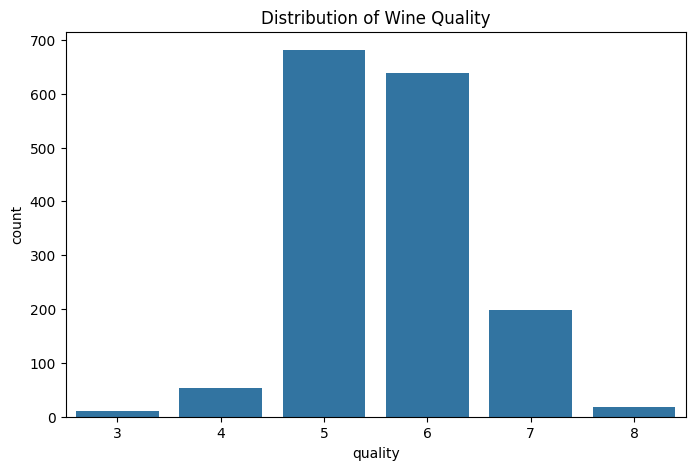

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="quality", data=df)
plt.title("Distribution of Wine Quality")
plt.show()

The graph above tells us that the majority of the wines' quality lie between the values of 5 and 6 while the low and high quality wines are comparatively low in number. This imbalance or bias is needed to be considered while handling such dataset and evaluation of the model being trained and tested.

Exploratory Data Analysis helps in understanding patterns, trends, and imbalances in the dataset before training a model. It allows us to make informed decisions about preprocessing steps, feature engineering, and model selection, ultimately leading to better model performance.

## Task 5: Convert to Binary Classification

In [ ]:
df["quality_label"] = np.where(df["quality"] >= 7, 1, 0)

In [ ]:
df[["quality", "quality_label"]].head()

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


In real-world business scenarios, decisions often need to be made quickly and efficiently. Predicting an exact quality score for wine adds unnecessary complexity and may not always be required for decision-making.

By using a threshold-based approach and converting the problem into a binary classification task, where wines with quality below 7 are labeled as 0 and those with quality 7 or above are labeled as 1, the system becomes simpler and more practical. This approach helps in faster evaluation, easier interpretation, and more actionable decision-making.

## TASK 6: Feature & Target Separation

In [ ]:
X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

We use Quality as the target variable and its necessary that we do not include it as input. In real life, models never know the target beforehand. We train the models based on nontarget variables to get the target variable then compare the predictions with acutal labels to get the accuracy. Including the target variable would mean that the model knows what the target variable should be and would thus cheat.

## TASK 7: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ML Models are trained and tested on different sections of the same data. We do this by splitting the dataset into training and testing data. The reason is if we train and test the model on the same set of data, the model would learn the outcomes and will get overfitted. Splitting the data so it is trained and tested on different sets of data means that from the training data it would learn patterns and from the testing data it would evaluate unseen data and would truly be tested.

## TASK 8: Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling is an important preprocessing step in machine learning that ensures all numerical features are on a similar scale. Without scaling, features with larger values can dominate the learning process and negatively affect model performance. Scaling helps models that rely on distance calculations or gradient-based optimization to learn patterns more effectively. However, tree-based models do not require feature scaling because they make decisions based on feature splits rather than distances.

## TASK 9: Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

Train Models:

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

accuracies = {}

for name, model in models.items():
    if name in ["Decision Tree", "Random Forest"]:
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)
    else:
        model.fit(X_train_scaled, y_train)
        acc = model.score(X_test_scaled, y_test)

    accuracies[name] = acc

**Logistic Regression**

Logistic Regression is a linear classification algorithm that predicts the probability of a data point belonging to a particular class using a sigmoid function. It works well for binary classification problems and is easy to interpret.


**K-Nearest Neighbors (KNN)**

KNN is a distance-based algorithm that classifies a data point based on the majority class of its nearest neighbors. It does not learn explicit parameters but relies on distance calculations between data points.


**Decision Tree Classifier**

A Decision Tree classifier works by recursively splitting the data based on feature values to make decisions. It creates a tree-like structure of rules that are easy to understand and interpret.


**Random Forest Classifier**

Random Forest is an ensemble learning method that combines multiple decision trees to make predictions. By averaging the results of many trees, it improves accuracy and reduces overfitting.


**Support Vector Machine (SVM)**

SVM is a classification algorithm that finds the optimal hyperplane that best separates the data into different classes. It is effective in high-dimensional spaces and works well with clear margins of separation.

## TASK 10: Model Comparison

In [ ]:
accuracy_df = pd.DataFrame(
    list(accuracies.items()),
    columns=["Model", "Accuracy"]
)

accuracy_df

,Model,Accuracy
0,Logistic Regression,0.865625
1,KNN,0.881250
2,Decision Tree,0.871875
3,Random Forest,0.900000
4,SVM,0.875000


After evaluating all the trained models using accuracy as the performance metric, the results were compared in a tabular format. Among the models tested, the Random Forest Classifier achieved the highest accuracy on the test dataset.

Random Forest performed better because it combines the predictions of multiple decision trees, allowing it to capture complex patterns in the data while reducing the risk of overfitting. It is also robust to noise and works well with non-linear relationships present in the dataset.

## TASK 11: Pipeline & Hyperparameter Tuning

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

📌 Pipeline + GridSearch

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"]
}

grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             param_grid={'svm__C': [0.1, 1, 10],
                         'svm__kernel': ['linear', 'rbf']})

📌 Best results

In [ ]:
grid.best_params_

{'svm__C': 10, 'svm__kernel': 'rbf'}

In [ ]:
grid.best_score_

np.float64(0.8944424019607844)

Machine learning pipelines are used to automate and standardize the workflow by combining multiple steps such as feature scaling and model training into a single process. This ensures consistency and prevents data leakage during model evaluation.

Hyperparameter tuning using GridSearchCV helps in finding the best combination of model parameters that result in optimal performance. By systematically testing different parameter values using cross-validation, the model becomes more generalized and performs better on unseen data.

# Conclusion
In this project, I worked on building an end-to-end machine learning system to predict wine quality using chemical properties. The dataset was explored thoroughly using data inspection and exploratory data analysis, which helped me understand feature distributions and class imbalance.

By converting the problem into a binary classification task, I made the prediction process more practical and aligned it with real-world decision-making. Multiple machine learning models were trained and evaluated, and the Random Forest classifier achieved the best performance.

Through this project, I learned the importance of data preprocessing, feature scaling, model selection, and evaluation techniques. This project closely resembles real-world machine learning applications, where understanding data and building reliable, scalable models is more important than simply achieving high accuracy.